# 03 - Prévision de consommation avec SARIMA / SARIMAX

Ce notebook entraîne un modèle SARIMA (ou SARIMAX avec variables exogènes) pour prédire la consommation journalière (`consommation_mw`).

**Variables exclues** : `prevision_j1_mw` et `prevision_j_mw` ne sont pas utilisées (ni en target, ni en feature, ni en ingénierie).

**Plan** :
1. Chargement et préparation de la série
2. Analyse de stationnarité (ADF, KPSS) + décomposition saisonnière
3. ACF / PACF pour guider le choix des ordres
4. Sélection automatique des hyperparamètres avec `auto_arima`
5. Validation walk-forward (expanding window)
6. Analyse des résidus et visualisation finale

In [23]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 0
sns.set_theme(style="whitegrid")

# Colonnes interdites (ne jamais utiliser en feature ni en target dérivée)
FORBIDDEN_COLUMNS = {"prevision_j1_mw", "prevision_j_mw"}

silver_path = (Path.cwd().parent / "data" / "silver" / "rte_sqr_daily_silver.parquet").resolve()
print(f"Silver path: {silver_path}")
if not silver_path.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {silver_path}\n"
        "Exécute d'abord src/scripts/bronze_to_silver.py"
    )

Silver path: /home/camille/code/Camille9999/EPSI/M2/EPSI-M2_MSPR/src/data/silver/rte_sqr_daily_silver.parquet


## 1. Chargement et préparation de la série

In [24]:
raw_df = pd.read_parquet(silver_path)
raw_df["date"] = pd.to_datetime(raw_df["date"], errors="coerce")
raw_df = raw_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

# Vérification qu'aucune colonne interdite n'est accidentellement utilisée
leaked = FORBIDDEN_COLUMNS.intersection(raw_df.columns)
print(f"Colonnes interdites présentes dans le dataset (seront ignorées) : {leaked}")

pca_columns = [c for c in raw_df.columns if c.startswith("temp_pc_")]
print(f"Shape : {raw_df.shape}")
print(f"Colonnes PCA de température : {pca_columns}")
display(raw_df.head())

Colonnes interdites présentes dans le dataset (seront ignorées) : {'prevision_j1_mw', 'prevision_j_mw'}
Shape : (4749, 8)
Colonnes PCA de température : ['temp_pc_01', 'temp_pc_02', 'temp_pc_03']


,date,consommation_mw,prevision_j1_mw,prevision_j_mw,production_mw,temp_pc_01,temp_pc_02,temp_pc_03
0,2012-01-01,51060.9375,50427.604167,492.6875,51003.770833,-3.338610,6.849751,5.413269
1,2012-01-02,60379.6875,59781.770833,491.614583,60323.71875,-14.100261,4.370491,0.697807
2,2012-01-03,66141.145833,66589.0625,514.572917,67282.197917,-15.249291,-1.146179,2.822054
3,2012-01-04,67244.270833,66988.541667,546.010417,67532.864583,-15.667742,3.208044,2.546018
4,2012-01-05,66772.395833,67546.875,537.635417,68645.729167,-12.303847,3.125173,5.623418


Valeurs manquantes après asfreq('D') : 0
Période : 2012-01-01 → 2024-12-31  (4749 jours)


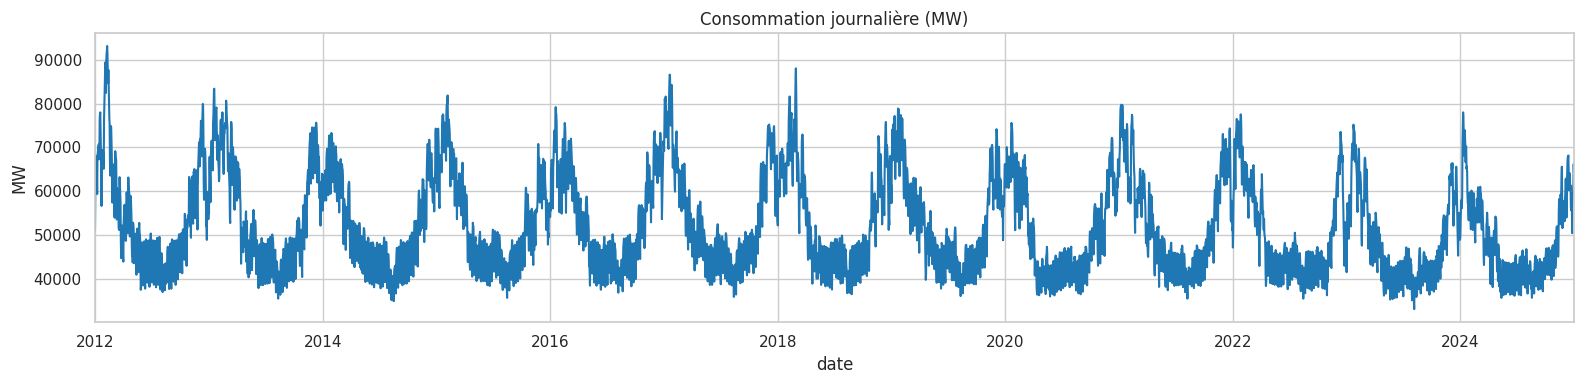

In [25]:
# Série cible avec index DatetimeIndex journalier
ts = raw_df.set_index("date")["consommation_mw"].asfreq("D")

n_missing = ts.isna().sum()
print(f"Valeurs manquantes après asfreq('D') : {n_missing}")
if n_missing > 0:
    # Interpolation linéaire pour les jours manquants
    ts = ts.interpolate(method="time")
    print(f"Valeurs manquantes après interpolation : {ts.isna().sum()}")

print(f"Période : {ts.index.min().date()} → {ts.index.max().date()}  ({len(ts)} jours)")
ts.plot(figsize=(16, 4), title="Consommation journalière (MW)", color="#1f77b4")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

## 2. Décomposition saisonnière & tests de stationnarité

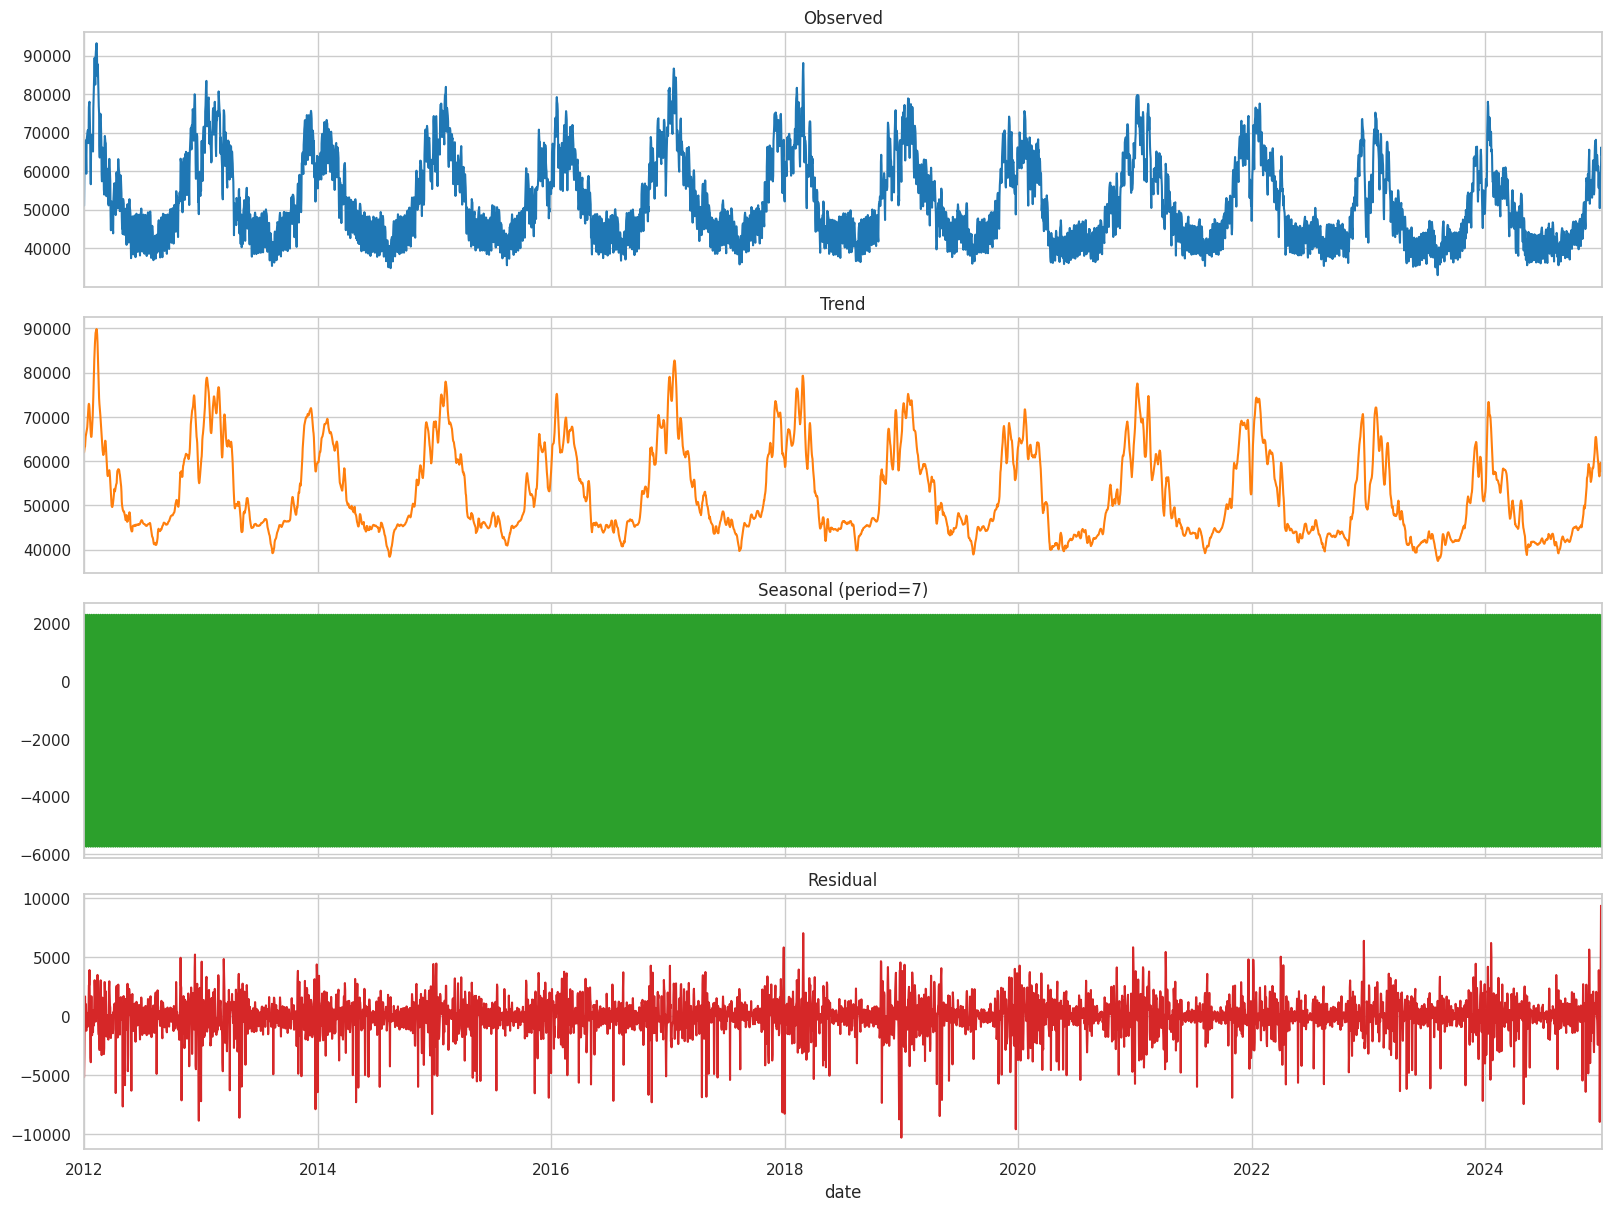

In [26]:
# Décomposition STL avec période hebdomadaire (7 jours)
decomposition = seasonal_decompose(ts, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True, constrained_layout=True)
decomposition.observed.plot(ax=axes[0], title="Observed", color="#1f77b4")
decomposition.trend.plot(ax=axes[1], title="Trend", color="#ff7f0e")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal (period=7)", color="#2ca02c")
decomposition.resid.plot(ax=axes[3], title="Residual", color="#d62728")
plt.show()

In [27]:
def stationarity_report(series: pd.Series, label: str = "Série") -> None:
    """Affiche les résultats ADF et KPSS."""
    adf_stat, adf_p, _, _, adf_cv, _ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, _, kpss_cv = kpss(series.dropna(), regression="c")

    print(f"\n{'='*50}")
    print(f" Stationnarité : {label}")
    print(f"{'='*50}")
    print(f"  ADF  stat={adf_stat:.4f}  p={adf_p:.4f}  → {'STATIONNAIRE' if adf_p < 0.05 else 'NON-STATIONNAIRE'}")
    print(f"  KPSS stat={kpss_stat:.4f}  p={kpss_p:.4f}  → {'NON-STATIONNAIRE' if kpss_p < 0.05 else 'STATIONNAIRE'}")


stationarity_report(ts, "consommation_mw")
stationarity_report(ts.diff().dropna(), "consommation_mw (diff 1)")
stationarity_report(ts.diff(7).dropna(), "consommation_mw (diff saisonnière 7)")


 Stationnarité : consommation_mw
  ADF  stat=-4.7283  p=0.0001  → STATIONNAIRE
  KPSS stat=0.5339  p=0.0340  → NON-STATIONNAIRE

 Stationnarité : consommation_mw (diff 1)
  ADF  stat=-14.9204  p=0.0000  → STATIONNAIRE
  KPSS stat=0.0141  p=0.1000  → STATIONNAIRE

 Stationnarité : consommation_mw (diff saisonnière 7)
  ADF  stat=-13.1339  p=0.0000  → STATIONNAIRE
  KPSS stat=0.0190  p=0.1000  → STATIONNAIRE


## 3. ACF / PACF

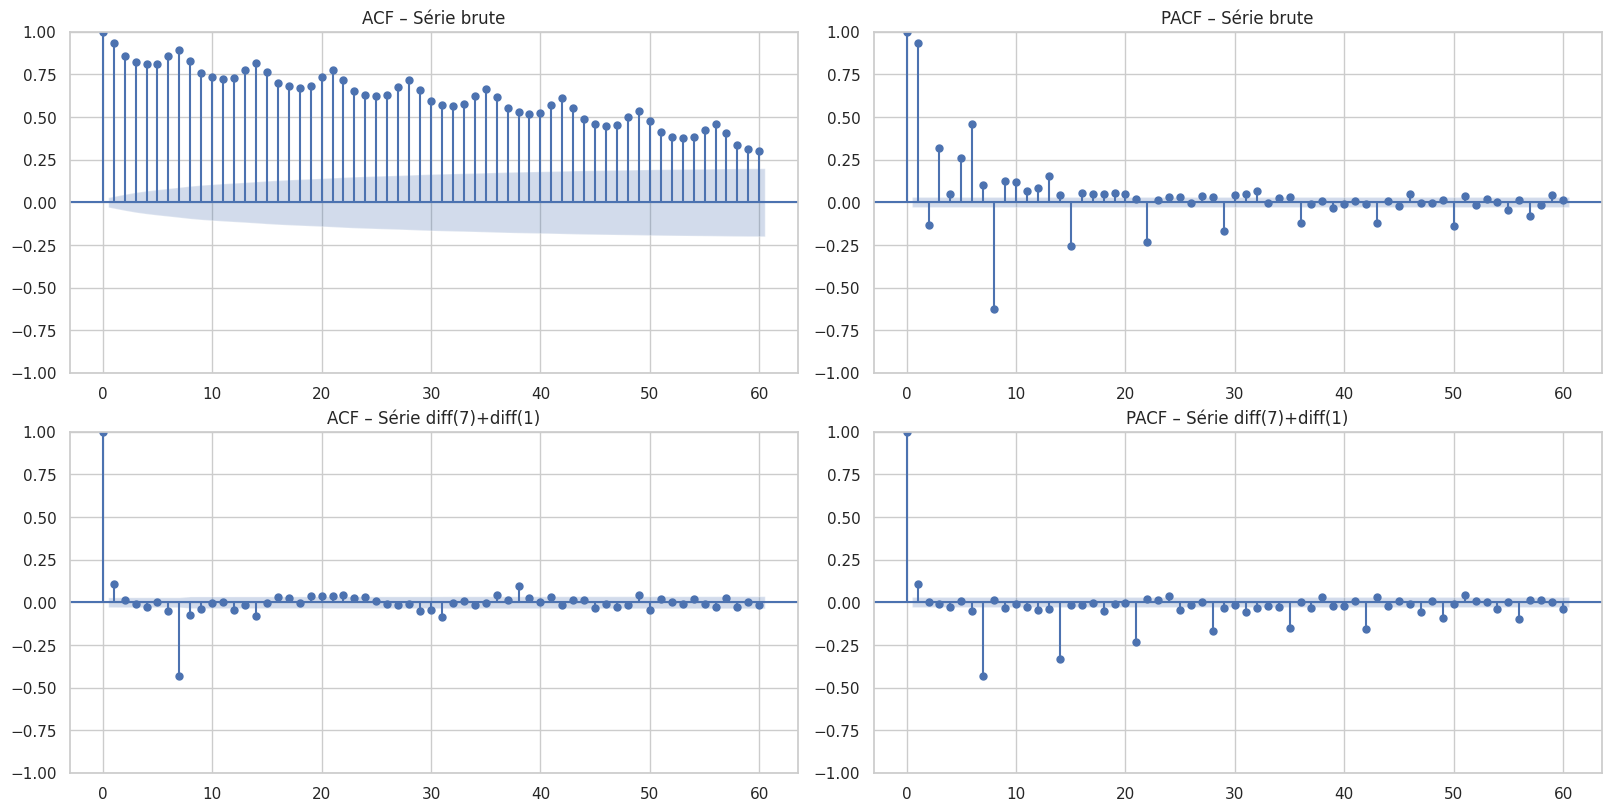

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)

plot_acf(ts.dropna(), lags=60, ax=axes[0, 0], title="ACF – Série brute")
plot_pacf(ts.dropna(), lags=60, ax=axes[0, 1], title="PACF – Série brute", method="ywm")

ts_diff = ts.diff(7).diff().dropna()
plot_acf(ts_diff, lags=60, ax=axes[1, 0], title="ACF – Série diff(7)+diff(1)")
plot_pacf(ts_diff, lags=60, ax=axes[1, 1], title="PACF – Série diff(7)+diff(1)", method="ywm")

plt.show()

## 4. Sélection automatique des hyperparamètres avec auto_arima

On cherche les ordres SARIMA(p,d,q)(P,D,Q)[7] sur un sous-ensemble d'entraînement.

In [35]:
# Construction des variables exogènes (hors colonnes interdites)
exog_full = raw_df.set_index("date")[["production_mw"] + pca_columns].asfreq("D")
exog_full = exog_full.interpolate(method="time")

# Variables calendaires cycliques
exog_full["dow_sin"] = np.sin(2 * np.pi * exog_full.index.dayofweek / 7)
exog_full["dow_cos"] = np.cos(2 * np.pi * exog_full.index.dayofweek / 7)
exog_full["doy_sin"] = np.sin(2 * np.pi * exog_full.index.dayofyear / 365.25)
exog_full["doy_cos"] = np.cos(2 * np.pi * exog_full.index.dayofyear / 365.25)
exog_full["is_weekend"] = (exog_full.index.dayofweek >= 5).astype(float)

# Lag-1 de production pour éviter toute fuite
exog_full["production_mw_lag1"] = exog_full["production_mw"].shift(1)
exog_full = exog_full.drop(columns=["production_mw"])
exog_full = exog_full.dropna().astype("float64")

# Aligner target et exog sur les mêmes dates
common_index = ts.index.intersection(exog_full.index)
ts_aligned = ts.loc[common_index]
exog_full = exog_full.loc[common_index]

assert not FORBIDDEN_COLUMNS.intersection(exog_full.columns), "Fuite détectée !"

# Modèle parcimonieux: on retire les calendaires explicites
calendar_columns = ["dow_sin", "dow_cos", "doy_sin", "doy_cos", "is_weekend"]
exog_parsimonious = exog_full.drop(columns=calendar_columns)

# Colonnes continues à standardiser
scale_columns = [column for column in pca_columns + ["production_mw_lag1"] if column in exog_full.columns]

print(f"Série cible            : {len(ts_aligned)} jours")
print(f"Exog full              : {list(exog_full.columns)}")
print(f"Exog parcimonieux      : {list(exog_parsimonious.columns)}")
print(f"Colonnes standardisées : {scale_columns}")
display(exog_full.head())

Série cible            : 4748 jours
Exog full              : ['temp_pc_01', 'temp_pc_02', 'temp_pc_03', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'is_weekend', 'production_mw_lag1']
Exog parcimonieux      : ['temp_pc_01', 'temp_pc_02', 'temp_pc_03', 'production_mw_lag1']
Colonnes standardisées : ['temp_pc_01', 'temp_pc_02', 'temp_pc_03', 'production_mw_lag1']


,temp_pc_01,temp_pc_02,temp_pc_03,dow_sin,dow_cos,doy_sin,doy_cos,is_weekend,production_mw_lag1
date,,,,,,,,,
2012-01-02,-14.100261,4.370491,0.697807,0.000000,1.000000,0.034398,0.999408,0.0,51003.770833
2012-01-03,-15.249291,-1.146179,2.822054,0.781831,0.623490,0.051584,0.998669,0.0,60323.718750
2012-01-04,-15.667742,3.208044,2.546018,0.974928,-0.222521,0.068755,0.997634,0.0,67282.197917
2012-01-05,-12.303847,3.125173,5.623418,0.433884,-0.900969,0.085906,0.996303,0.0,67532.864583
2012-01-06,-18.074701,3.641802,0.802973,-0.433884,-0.900969,0.103031,0.994678,0.0,68645.729167


In [36]:
# Réservation des 2 premières années pour la sélection d'ordre
TRAIN_DAYS_AUTOARIMA = 365 * 2

ts_train_auto = ts_aligned.iloc[:TRAIN_DAYS_AUTOARIMA]
exog_train_auto = exog_full.iloc[:TRAIN_DAYS_AUTOARIMA]

print(f"Auto-arima sur {len(ts_train_auto)} jours ({ts_train_auto.index.min().date()} → {ts_train_auto.index.max().date()})")

auto_model = pm.auto_arima(
    ts_train_auto,
    X=exog_train_auto.values,
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    d=None,               # laisse auto_arima choisir d
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    D=1,                  # différenciation saisonnière forcée à 1
    m=7,                  # périodicité hebdomadaire
    seasonal=True,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True,
)

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print(f"\nOrdres sélectionnés : SARIMA{order}x{seasonal_order}")
print(f"AIC : {auto_model.aic():.2f}")

Auto-arima sur 730 jours (2012-01-02 → 2013-12-31)
Performing stepwise search to minimize aic


 ARIMA(1,0,1)(0,1,0)[7] intercept   : AIC=13235.711, Time=5.70 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=13272.370, Time=0.91 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=13160.801, Time=10.97 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=inf, Time=15.12 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=13270.457, Time=1.73 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=13233.721, Time=2.40 sec
 ARIMA(1,0,0)(2,1,0)[7] intercept   : AIC=13128.799, Time=6.42 sec
 ARIMA(1,0,0)(2,1,1)[7] intercept   : AIC=inf, Time=21.21 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=16.72 sec
 ARIMA(0,0,0)(2,1,0)[7] intercept   : AIC=13159.598, Time=15.29 sec
 ARIMA(2,0,0)(2,1,0)[7] intercept   : AIC=13130.168, Time=5.32 sec
 ARIMA(1,0,1)(2,1,0)[7] intercept   : AIC=13119.507, Time=23.28 sec
 ARIMA(1,0,1)(1,1,0)[7] intercept   : AIC=13158.214, Time=13.11 sec
 ARIMA(1,0,1)(2,1,1)[7] intercept   : AIC=inf, Time=18.37 sec
 ARIMA(1,0,1)(1,1,1)[7] intercept   : AIC=inf, Time=21.73 sec
 ARIMA(0,0,1)(2,

## 5. Optimisations: sélection de variables, scaling, backtest multi-horizons

Cette section applique les optimisations suivantes :
- comparaison de 3 jeux d'exogènes (`full`, `significatives`, `parcimonieux`) ;
- standardisation des variables continues (`temp_pc_*`, `production_mw_lag1`) ;
- évaluation walk-forward sur deux horizons (`t+1`, `t+7`).

In [ ]:
INITIAL_TRAIN_DAYS = 365 * 2
REFIT_EVERY = 30
HORIZONS = [1, 7]
BACKTEST_MAX_STEPS = 1000  # réduire le temps de calcul; mets None pour tout l'historique
P_VALUE_THRESHOLD = 0.10
MIN_SIGNIFICANT_FEATURES = 3


def walk_forward_sarimax(
    y: pd.Series,
    exog: pd.DataFrame,
    order: tuple,
    seasonal_order: tuple,
    horizon: int,
    initial_train_days: int,
    refit_every: int,
    scale_cols: list[str] | None = None,
    max_steps: int | None = None,
) -> pd.DataFrame:
    y = y.astype("float64")
    exog = exog.astype("float64").copy()

    start_idx = initial_train_days
    end_idx = len(y) - horizon + 1
    eval_indices = list(range(start_idx, end_idx))

    if max_steps is not None and len(eval_indices) > max_steps:
        eval_indices = eval_indices[-max_steps:]

    current_model = None
    rows = []

    print(
        f"Walk-forward horizon t+{horizon}: {len(eval_indices)} pas "
        f"(refit={refit_every}, max_steps={max_steps})"
    )

    for step, i in enumerate(eval_indices):
        train_y = y.iloc[:i]
        train_x_df = exog.iloc[:i].copy().astype("float64")
        test_x_df = exog.iloc[i : i + horizon].copy().astype("float64")

        if scale_cols:
            cols = [c for c in scale_cols if c in train_x_df.columns]
            if cols:
                scaler = StandardScaler()
                train_x_df.loc[:, cols] = scaler.fit_transform(train_x_df[cols]).astype("float64")
                test_x_df.loc[:, cols] = scaler.transform(test_x_df[cols]).astype("float64")

        train_x = train_x_df.to_numpy(dtype="float64")
        test_x = test_x_df.to_numpy(dtype="float64")

        if step % refit_every == 0:
            current_model = SARIMAX(
                train_y,
                exog=train_x,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
        else:
            current_model = current_model.apply(train_y, exog=train_x, refit=False)

        forecast = current_model.forecast(steps=horizon, exog=test_x)
        pred = float(forecast.iloc[-1])
        target_date = y.index[i + horizon - 1]
        actual = float(y.iloc[i + horizon - 1])

        rows.append({
            "date": target_date,
            "horizon": horizon,
            "actual": actual,
            "predicted": pred,
            "error": pred - actual,
            "abs_error": abs(pred - actual),
        })

        if step % 100 == 0:
            print(f"  step {step}/{len(eval_indices)}")

    return pd.DataFrame(rows)


# Sélection des variables significatives à partir d'un fit de sondage
probe_y = ts_aligned.iloc[:INITIAL_TRAIN_DAYS].astype("float64")
probe_x = exog_full.iloc[:INITIAL_TRAIN_DAYS].copy().astype("float64")

probe_x_scaled = probe_x.copy()
scaler_probe = StandardScaler()
probe_cols = [c for c in scale_columns if c in probe_x_scaled.columns]
probe_x_scaled.loc[:, probe_cols] = scaler_probe.fit_transform(probe_x_scaled[probe_cols]).astype("float64")

probe_model = SARIMAX(
    probe_y,
    exog=probe_x_scaled.to_numpy(dtype="float64"),
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

exog_columns = probe_x_scaled.columns.tolist()
exog_pvalues = pd.Series(probe_model.pvalues[: len(exog_columns)], index=exog_columns)
exog_coef_abs = pd.Series(np.abs(probe_model.params[: len(exog_columns)]), index=exog_columns)

nan_ratio = exog_pvalues.isna().mean()
print(f"Part de p-values NaN: {nan_ratio:.0%}")

if exog_pvalues.notna().sum() >= MIN_SIGNIFICANT_FEATURES:
    selected_significant_columns = [
        column
        for column, pval in exog_pvalues.items()
        if (pd.notna(pval) and pval <= P_VALUE_THRESHOLD) or (column == "production_mw_lag1")
    ]
    selection_method = f"p-value <= {P_VALUE_THRESHOLD}"
else:
    # Fallback robuste quand covariance singulière / p-values indisponibles
    top_by_coef = exog_coef_abs.sort_values(ascending=False).head(max(MIN_SIGNIFICANT_FEATURES, 4)).index.tolist()
    selected_significant_columns = sorted(set(top_by_coef + ["production_mw_lag1"]))
    selection_method = "fallback sur |coefs| standardisés (p-values NaN)"

exog_significant = exog_full[selected_significant_columns].copy()

print("\nP-values exog (fit de sondage):")
display(exog_pvalues)
print("|Coef| exog (fit de sondage):")
display(exog_coef_abs.sort_values(ascending=False))
print(f"Méthode de sélection: {selection_method}")
print(f"Colonnes significatives retenues: {selected_significant_columns}")

model_specs = {
    "full": exog_full,
    "significatives": exog_significant,
    "parcimonieux": exog_parsimonious,
}

all_results = {}

for model_name, exog_df in model_specs.items():
    for horizon in HORIZONS:
        wf = walk_forward_sarimax(
            y=ts_aligned,
            exog=exog_df,
            order=order,
            seasonal_order=seasonal_order,
            horizon=horizon,
            initial_train_days=INITIAL_TRAIN_DAYS,
            refit_every=REFIT_EVERY,
            scale_cols=scale_columns,
            max_steps=BACKTEST_MAX_STEPS,
        )
        all_results[(model_name, horizon)] = wf

print("\nBacktests terminés.")


P-values exog (fit de sondage):


temp_pc_01           NaN
temp_pc_02           NaN
temp_pc_03           NaN
dow_sin              NaN
dow_cos              NaN
doy_sin              NaN
doy_cos              NaN
is_weekend           NaN
production_mw_lag1   NaN
dtype: float64

Colonnes significatives retenues (p <= 0.1): ['production_mw_lag1']
Walk-forward horizon t+1: 1000 pas (refit=30, max_steps=1000)
  step 0/1000
  step 100/1000
  step 200/1000
  step 300/1000
  step 400/1000
  step 500/1000
  step 600/1000
  step 700/1000
  step 800/1000
  step 900/1000
Walk-forward horizon t+7: 1000 pas (refit=30, max_steps=1000)
  step 0/1000
  step 100/1000
  step 200/1000
  step 300/1000
  step 400/1000
  step 500/1000
  step 600/1000
  step 700/1000
  step 800/1000
  step 900/1000
Walk-forward horizon t+1: 1000 pas (refit=30, max_steps=1000)
  step 0/1000
  step 100/1000
  step 200/1000
  step 300/1000
  step 400/1000
  step 500/1000
  step 600/1000
  step 700/1000
  step 800/1000
  step 900/1000
Walk-forward horizon t+7: 1000 pas (refit=30, max_steps=1000)
  step 0/1000
  step 100/1000
  step 200/1000
  step 300/1000
  step 400/1000
  step 500/1000
  step 600/1000
  step 700/1000
  step 800/1000
  step 900/1000
Walk-forward horizon t+1: 1000 pas (refit=30, max_st

In [66]:
PEAK_QUANTILE = 0.90
MIN_CONTEXT_POINTS = 20
summary_rows = []

for (model_name, horizon), wf in all_results.items():
    d = wf.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["month"] = d["date"].dt.month
    d["day_of_week"] = d["date"].dt.dayofweek

    y_true = d["actual"].to_numpy()
    y_pred = d["predicted"].to_numpy()

    # Pics contextuels: seuil relatif au contexte saisonnier local (mois x jour de semaine)
    d["context_count"] = d.groupby(["month", "day_of_week"])["actual"].transform("count")
    d["peak_threshold_ctx"] = d.groupby(["month", "day_of_week"])["actual"].transform(
        lambda s: s.quantile(PEAK_QUANTILE)
    )
    d["peak_threshold_global"] = float(d["actual"].quantile(PEAK_QUANTILE))
    d["peak_threshold"] = np.where(
        d["context_count"] >= MIN_CONTEXT_POINTS,
        d["peak_threshold_ctx"],
        d["peak_threshold_global"],
    )

    peak_mask = d["actual"] >= d["peak_threshold"]
    d_peak = d.loc[peak_mask]

    if len(d_peak) > 0:
        peak_true = d_peak["actual"].to_numpy()
        peak_pred = d_peak["predicted"].to_numpy()
        peak_mae = mean_absolute_error(peak_true, peak_pred)
        peak_rmse = float(np.sqrt(mean_squared_error(peak_true, peak_pred)))
        underforecast_rate_peak = float((peak_pred < peak_true).mean())
    else:
        peak_mae = np.nan
        peak_rmse = np.nan
        underforecast_rate_peak = np.nan

    summary_rows.append({
        "model_name": model_name,
        "horizon": horizon,
        "n_points": len(d),
        "MAE_MW": mean_absolute_error(y_true, y_pred),
        "RMSE_MW": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE_pct": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "peak_threshold_global_MW": float(d["peak_threshold_global"].iloc[0]),
        "peak_threshold_context_median_MW": float(d["peak_threshold"].median()),
        "n_peak_points": int(peak_mask.sum()),
        "peak_MAE_MW": peak_mae,
        "peak_RMSE_MW": peak_rmse,
        "underforecast_rate_peak": underforecast_rate_peak,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["horizon", "peak_RMSE_MW"]).reset_index(drop=True)

# Rangs par horizon (plus petit = meilleur)
summary_df["rank_mape"] = summary_df.groupby("horizon")["MAPE_pct"].rank(method="min")
summary_df["rank_mae"] = summary_df.groupby("horizon")["MAE_MW"].rank(method="min")
summary_df["rank_rmse"] = summary_df.groupby("horizon")["RMSE_MW"].rank(method="min")
summary_df["rank_peak_mae"] = summary_df.groupby("horizon")["peak_MAE_MW"].rank(method="min")
summary_df["rank_peak_rmse"] = summary_df.groupby("horizon")["peak_RMSE_MW"].rank(method="min")

# Compromis orienté pics: on pondère davantage les métriques de pics
summary_df["rank_peak_priority"] = (
    0.45 * summary_df["rank_peak_rmse"]
    + 0.35 * summary_df["rank_peak_mae"]
    + 0.20 * summary_df["rank_rmse"]
)

print(
    f"Résultats comparatifs (pics contextuels = quantile {PEAK_QUANTILE:.0%} par mois x jour, "
    f"fallback global si n<{MIN_CONTEXT_POINTS}):"
)
display(
    summary_df.sort_values(["horizon", "rank_peak_priority", "peak_RMSE_MW"]).reset_index(drop=True)
)

selection_by_metric = {}
for horizon in HORIZONS:
    horizon_df = summary_df[summary_df["horizon"] == horizon].copy()
    selection_by_metric[horizon] = {
        "best_peak_rmse": horizon_df.sort_values("peak_RMSE_MW").iloc[0]["model_name"],
        "best_peak_mae": horizon_df.sort_values("peak_MAE_MW").iloc[0]["model_name"],
        "best_rmse": horizon_df.sort_values("RMSE_MW").iloc[0]["model_name"],
        "best_mape": horizon_df.sort_values("MAPE_pct").iloc[0]["model_name"],
        "best_peak_priority": horizon_df.sort_values("rank_peak_priority").iloc[0]["model_name"],
    }

selection_df = pd.DataFrame([
    {
        "horizon": h,
        "best_peak_rmse": picks["best_peak_rmse"],
        "best_peak_mae": picks["best_peak_mae"],
        "best_rmse": picks["best_rmse"],
        "best_mape": picks["best_mape"],
        "best_peak_priority": picks["best_peak_priority"],
    }
    for h, picks in selection_by_metric.items()
]).sort_values("horizon")

print("Sélection par métrique (par horizon):")
display(selection_df)

# On garde les deux horizons, avec priorité métier sur les pics
selected_models_by_horizon = {
    horizon: selection_by_metric[horizon]["best_peak_priority"]
    for horizon in HORIZONS
}

wf_by_horizon = {
    horizon: all_results[(selected_models_by_horizon[horizon], horizon)].copy()
    for horizon in HORIZONS
}

print(f"Modèles retenus (priorité pics contextuels) par horizon: {selected_models_by_horizon}")
for horizon in HORIZONS:
    print(f"\nAperçu horizon t+{horizon}:")
    display(wf_by_horizon[horizon].head(5))

Résultats comparatifs (pics contextuels = quantile 90% par mois x jour, fallback global si n<20):


,model_name,horizon,n_points,MAE_MW,RMSE_MW,MAPE_pct,peak_threshold_global_MW,peak_threshold_context_median_MW,n_peak_points,peak_MAE_MW,peak_RMSE_MW,underforecast_rate_peak,rank_mape,rank_mae,rank_rmse,rank_peak_mae,rank_peak_rmse,rank_peak_priority
0,full,1,1000,1246.399304,1764.044073,2.684874,61350.572917,61350.572917,100,1149.247248,1608.077260,0.49,3.0,1.0,1.0,1.0,1.0,1.0
1,parcimonieux,1,1000,1246.465827,1764.617987,2.682589,61350.572917,61350.572917,100,1155.222610,1608.851590,0.49,2.0,2.0,2.0,2.0,2.0,2.0
2,significatives,1,1000,1284.144204,1895.554142,2.669471,61350.572917,61350.572917,100,1574.858940,2127.146069,0.56,1.0,3.0,3.0,3.0,3.0,3.0
3,full,7,1000,1335.995169,1827.703671,2.881352,61350.572917,61350.572917,100,1273.878483,1722.855080,0.55,3.0,3.0,2.0,1.0,1.0,1.2
4,parcimonieux,7,1000,1333.883729,1826.313546,2.873166,61350.572917,61350.572917,100,1285.443066,1730.066789,0.55,2.0,2.0,1.0,2.0,2.0,1.8
5,significatives,7,1000,1328.471302,1925.357680,2.747666,61350.572917,61350.572917,100,1757.524009,2317.915687,0.57,1.0,1.0,3.0,3.0,3.0,3.0


Sélection par métrique (par horizon):


,horizon,best_peak_rmse,best_peak_mae,best_rmse,best_mape,best_peak_priority
0,1,full,full,full,significatives,full
1,7,full,full,parcimonieux,significatives,full


Modèles retenus (priorité pics contextuels) par horizon: {1: 'full', 7: 'full'}

Aperçu horizon t+1:


,date,horizon,actual,predicted,error,abs_error
0,2022-04-07,1,54761.979167,57517.311399,2755.332232,2755.332232
1,2022-04-08,1,55447.916667,56297.837282,849.920615,849.920615
2,2022-04-09,1,52620.833333,52406.817933,-214.015401,214.015401
3,2022-04-10,1,51092.708333,49895.657287,-1197.051047,1197.051047
4,2022-04-11,1,53628.125000,54556.747059,928.622059,928.622059



Aperçu horizon t+7:


,date,horizon,actual,predicted,error,abs_error
0,2022-04-07,7,54761.979167,57769.633741,3007.654574,3007.654574
1,2022-04-08,7,55447.916667,57074.847152,1626.930486,1626.930486
2,2022-04-09,7,52620.833333,52985.532905,364.699571,364.699571
3,2022-04-10,7,51092.708333,50169.286234,-923.422099,923.422099
4,2022-04-11,7,53628.125000,54462.401891,834.276891,834.276891


## 6. Visualisation des prévisions et analyse des résidus

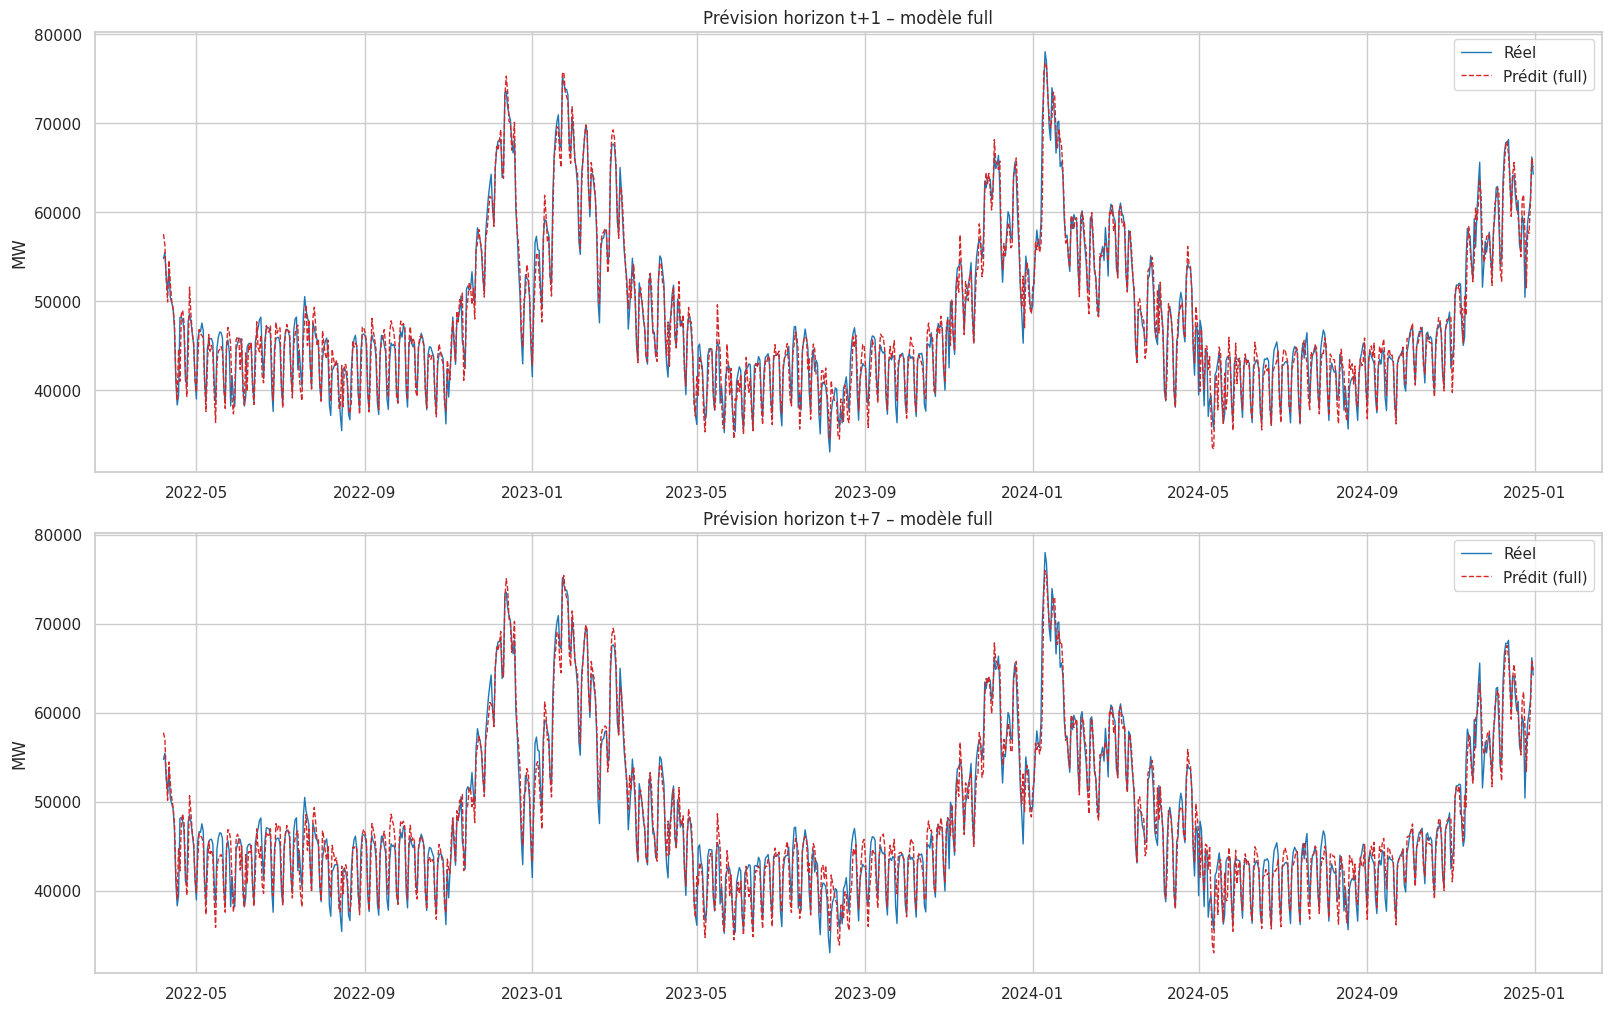

In [67]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(16, 5 * len(HORIZONS)), constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    wf_h = wf_by_horizon[horizon]
    model_name = selected_models_by_horizon[horizon]

    ax.plot(wf_h["date"], wf_h["actual"], label="Réel", linewidth=1.0, color="#1f77b4")
    ax.plot(
        wf_h["date"],
        wf_h["predicted"],
        label=f"Prédit ({model_name})",
        linewidth=1.0,
        color="#d62728",
        linestyle="--",
    )
    ax.set_title(f"Prévision horizon t+{horizon} – modèle {model_name}")
    ax.set_ylabel("MW")
    ax.legend()

plt.show()

In [68]:
# Entraîner un modèle final par horizon (avec son jeu d'exogènes retenu)
final_models_by_horizon = {}

for horizon in HORIZONS:
    model_name = selected_models_by_horizon[horizon]
    selected_exog = model_specs[model_name].copy()

    final_y = ts_aligned.astype("float64")
    final_x_df = selected_exog.copy().astype("float64")

    final_scale_cols = [column for column in scale_columns if column in final_x_df.columns]
    if final_scale_cols:
        scaler_final = StandardScaler()
        final_x_df.loc[:, final_scale_cols] = scaler_final.fit_transform(final_x_df[final_scale_cols]).astype("float64")

    final_x = final_x_df.to_numpy(dtype="float64")

    final_model = SARIMAX(
        final_y,
        exog=final_x,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    final_models_by_horizon[horizon] = {
        "model_name": model_name,
        "model": final_model,
        "exog_columns": list(final_x_df.columns),
    }

for horizon in HORIZONS:
    payload = final_models_by_horizon[horizon]
    print(f"\n===== Horizon t+{horizon} | modèle {payload['model_name']} =====")
    print(f"Exog finales: {payload['exog_columns']}")
    print(payload["model"].summary())


===== Horizon t+1 | modèle full =====
Exog finales: ['temp_pc_01', 'temp_pc_02', 'temp_pc_03', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'is_weekend', 'production_mw_lag1']
                                     SARIMAX Results                                      
Dep. Variable:                    consommation_mw   No. Observations:                 4748
Model:             SARIMAX(2, 0, 1)x(2, 1, [], 7)   Log Likelihood              -42432.210
Date:                            Fri, 24 Apr 2026   AIC                          84894.420
Time:                                    16:48:46   BIC                          84991.329
Sample:                                01-02-2012   HQIC                         84928.482
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------

Diagnostics résidus – horizon t+1 (full)


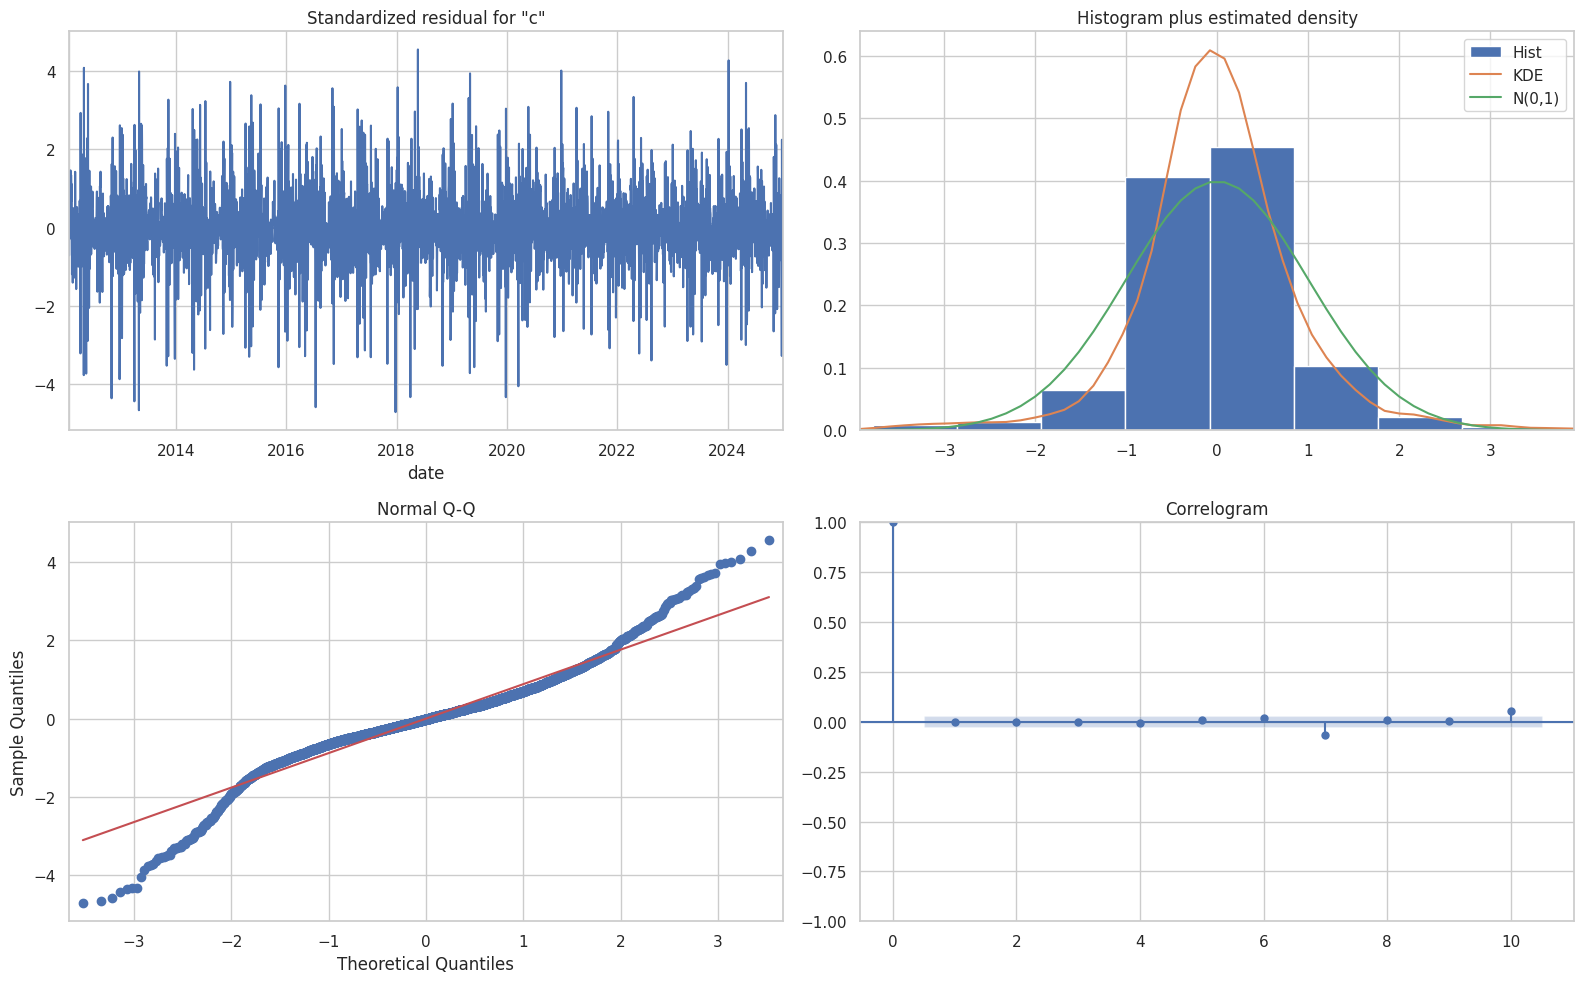

Diagnostics résidus – horizon t+7 (full)


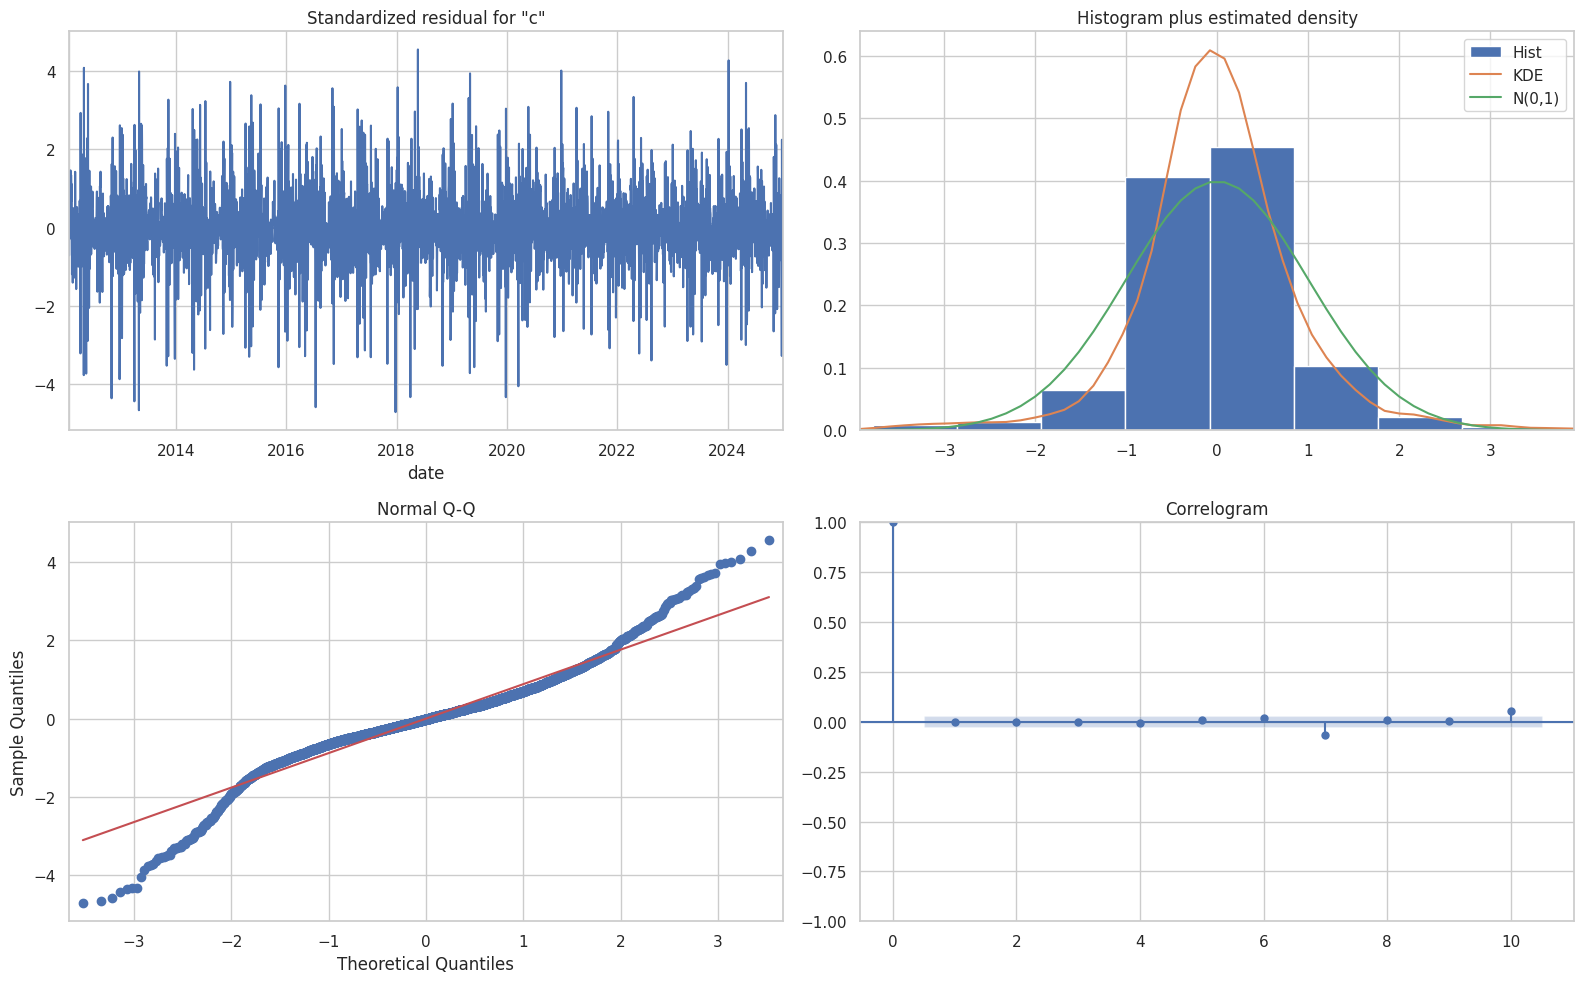

In [69]:
for horizon in HORIZONS:
    payload = final_models_by_horizon[horizon]
    print(f"Diagnostics résidus – horizon t+{horizon} ({payload['model_name']})")
    fig = payload["model"].plot_diagnostics(figsize=(16, 10))
    plt.tight_layout()
    plt.show()

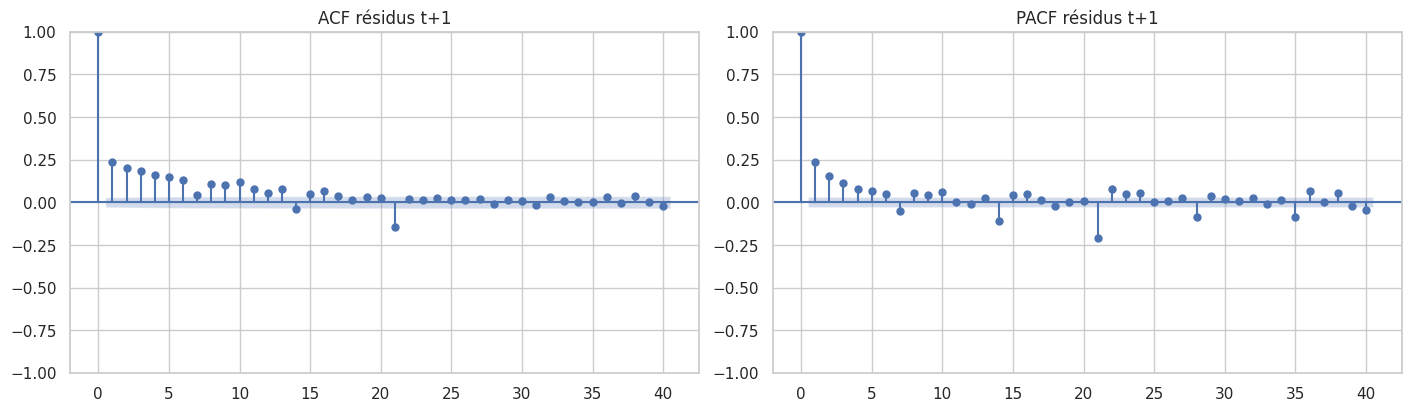

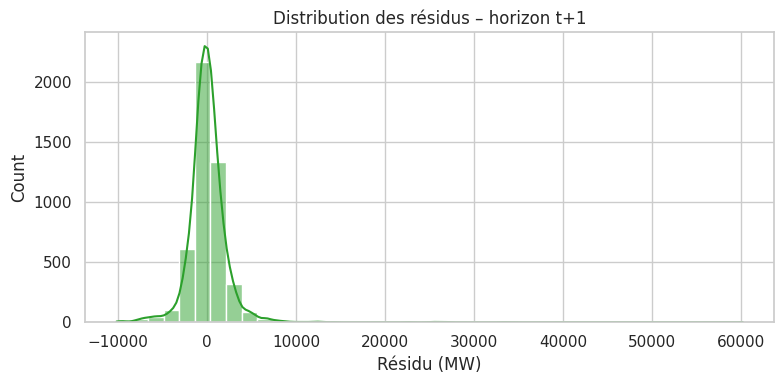

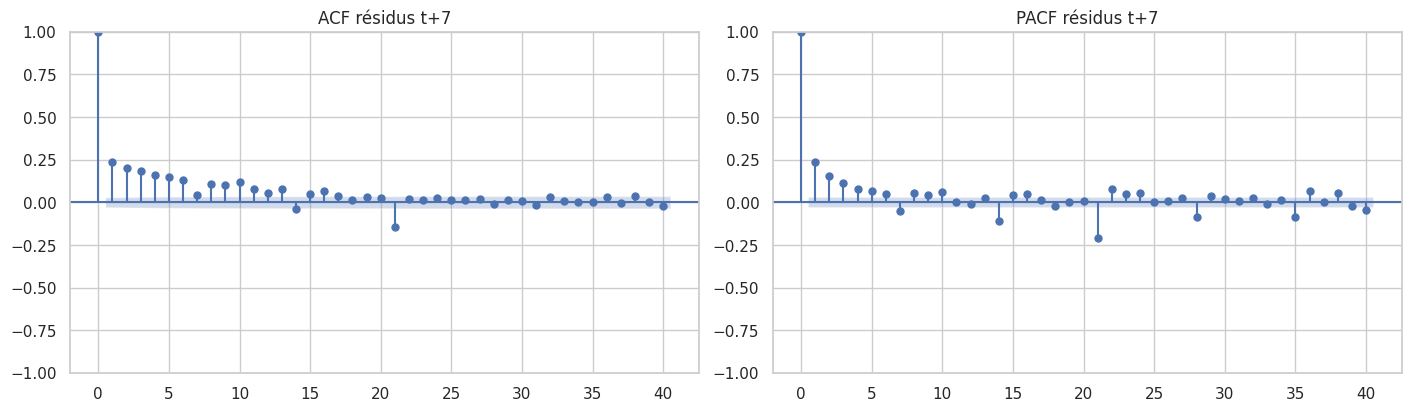

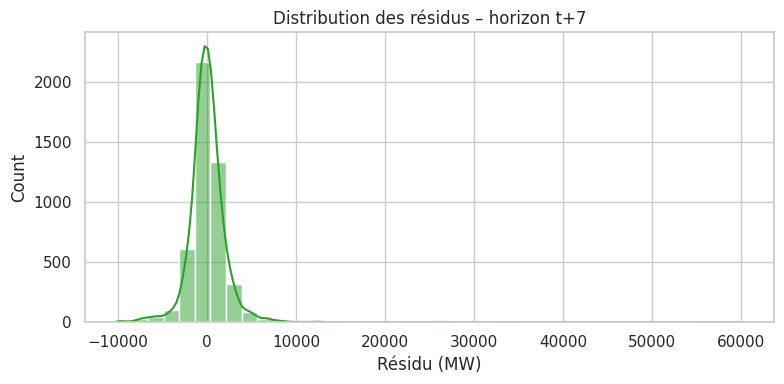

In [70]:
for horizon in HORIZONS:
    payload = final_models_by_horizon[horizon]
    residuals = payload["model"].resid

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    plot_acf(residuals.dropna(), lags=40, ax=axes[0], title=f"ACF résidus t+{horizon}")
    plot_pacf(residuals.dropna(), lags=40, ax=axes[1], title=f"PACF résidus t+{horizon}", method="ywm")
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.histplot(residuals.dropna(), bins=40, kde=True, color="#2ca02c")
    plt.title(f"Distribution des résidus – horizon t+{horizon}")
    plt.xlabel("Résidu (MW)")
    plt.tight_layout()
    plt.show()

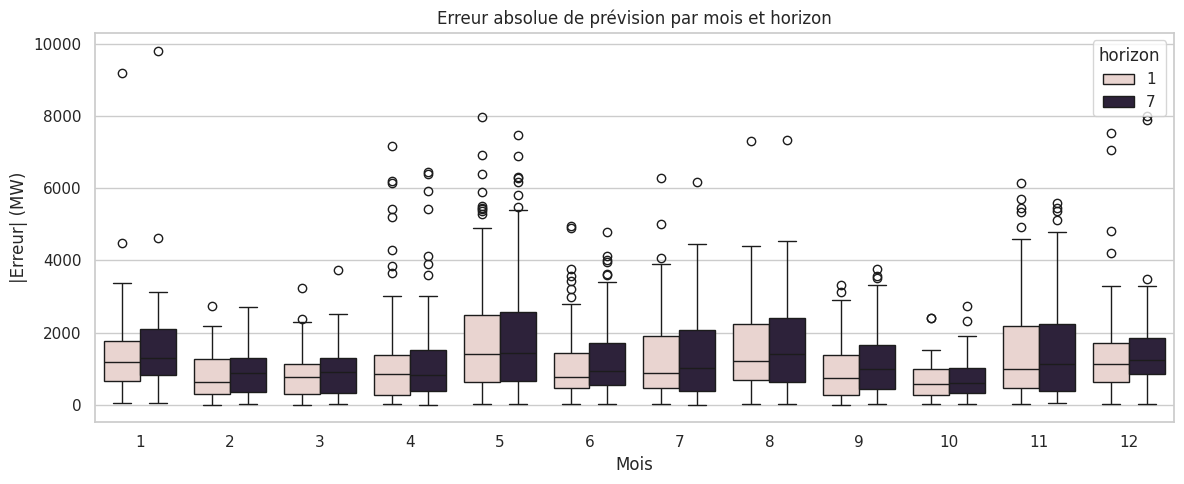

MAE_mean  MAE_median  MAE_std
horizon month                               
1       1        1429.4      1174.1   1350.2
        2         814.4       637.0    654.6
        3         864.9       755.1    680.7
        4        1276.7       847.6   1513.8
        5        1888.8      1398.7   1789.1
        6        1119.7       757.2   1045.8
        7        1254.4       874.6   1171.3
        8        1507.5      1201.0   1210.0
        9         943.3       732.1    818.3
        10        656.5       559.2    472.8
        11       1590.7       978.4   1505.9
        12       1377.4      1137.2   1273.0
7       1        1565.5      1301.0   1414.1
        2         916.3       880.1    694.7
        3         904.0       918.4    714.8
        4        1251.6       821.4   1396.7
        5        1929.1      1424.2   1746.2
        6        1283.0       935.5   1080.9
        7        1334.9      1005.3   1186.1
        8        1666.5      1411.3   1277.0
        9        1190.3       974.9    931.3
        10        723.7       587.6    529.6
        11       1542.5      1114.4   1456.4
        12       1486.7      1242.5   1261.7

In [71]:
wf_long = pd.concat(
    [
        wf_by_horizon[h].assign(horizon=h)
        for h in HORIZONS
    ],
    ignore_index=True,
)

wf_long["month"] = pd.to_datetime(wf_long["date"]).dt.month

plt.figure(figsize=(12, 5))
sns.boxplot(data=wf_long, x="month", y="abs_error", hue="horizon")
plt.title("Erreur absolue de prévision par mois et horizon")
plt.xlabel("Mois")
plt.ylabel("|Erreur| (MW)")
plt.tight_layout()
plt.show()

monthly_metrics = (
    wf_long.groupby(["horizon", "month"])[["abs_error"]]
    .agg(["mean", "median", "std"])
    .round(1)
)
monthly_metrics.columns = ["MAE_mean", "MAE_median", "MAE_std"]
display(monthly_metrics)

## 7. Data Visualisation Avancée (focus pics et robustesse)

Cette section ajoute des visualisations orientées exploitation:
- comportement sur les pics de charge ;
- stabilité temporelle de l'erreur ;
- calibration (réel vs prédit) ;
- qualité de détection des jours de pic ;
- saisonnalité des erreurs (mois x jour de semaine).

In [72]:
# Dataset long enrichi pour visualisations avancées
viz_peak_quantile = 0.90
viz_min_context_points = 20

if "wf_long" not in locals():
    wf_long = pd.concat(
        [wf_by_horizon[h].assign(horizon=h) for h in HORIZONS],
        ignore_index=True,
    )

wf_viz = wf_long.copy()
wf_viz["date"] = pd.to_datetime(wf_viz["date"])
wf_viz["month"] = wf_viz["date"].dt.month
wf_viz["day_of_week"] = wf_viz["date"].dt.dayofweek
wf_viz["day_name"] = wf_viz["date"].dt.day_name()
wf_viz["sq_error"] = wf_viz["error"] ** 2

# Seuil de pic contextuel par horizon + mois + jour de semaine
wf_viz["context_count"] = wf_viz.groupby(["horizon", "month", "day_of_week"])["actual"].transform("count")
wf_viz["peak_threshold_ctx"] = wf_viz.groupby(["horizon", "month", "day_of_week"])["actual"].transform(
    lambda s: s.quantile(viz_peak_quantile)
)
wf_viz["peak_threshold_horizon"] = wf_viz.groupby("horizon")["actual"].transform(
    lambda s: s.quantile(viz_peak_quantile)
)
wf_viz["peak_threshold"] = np.where(
    wf_viz["context_count"] >= viz_min_context_points,
    wf_viz["peak_threshold_ctx"],
    wf_viz["peak_threshold_horizon"],
)
wf_viz["is_peak"] = wf_viz["actual"] >= wf_viz["peak_threshold"]

threshold_summary = (
    wf_viz.groupby("horizon")
    .agg(
        threshold_median=("peak_threshold", "median"),
        threshold_min=("peak_threshold", "min"),
        threshold_max=("peak_threshold", "max"),
        n_peaks=("is_peak", "sum"),
        n_points=("is_peak", "count"),
    )
    .reset_index()
)
threshold_summary["peak_share_pct"] = 100 * threshold_summary["n_peaks"] / threshold_summary["n_points"]

print(
    f"Seuil de pic contextuel (q={viz_peak_quantile:.0%}, contexte mois x jour de semaine, "
    f"fallback horizon si n<{viz_min_context_points}):"
)
display(threshold_summary)
display(wf_viz.head())

Seuil de pic contextuel (q=90%, contexte mois x jour de semaine, fallback horizon si n<20):


,horizon,threshold_median,threshold_min,threshold_max,n_peaks,n_points,peak_share_pct
0,1,61350.572917,61350.572917,61350.572917,100,1000,10.0
1,7,61350.572917,61350.572917,61350.572917,100,1000,10.0


,date,horizon,actual,predicted,error,abs_error,month,day_of_week,day_name,sq_error,context_count,peak_threshold_ctx,peak_threshold_horizon,peak_threshold,is_peak
0,2022-04-07,1,54761.979167,57517.311399,2755.332232,2755.332232,4,3,Thursday,7.591856e+06,12,53695.885417,61350.572917,61350.572917,False
1,2022-04-08,1,55447.916667,56297.837282,849.920615,849.920615,4,4,Friday,7.223651e+05,12,51924.635417,61350.572917,61350.572917,False
2,2022-04-09,1,52620.833333,52406.817933,-214.015401,214.015401,4,5,Saturday,4.580259e+04,13,46428.437500,61350.572917,61350.572917,False
3,2022-04-10,1,51092.708333,49895.657287,-1197.051047,1197.051047,4,6,Sunday,1.432931e+06,12,45340.520833,61350.572917,61350.572917,False
4,2022-04-11,1,53628.125000,54556.747059,928.622059,928.622059,4,0,Monday,8.623389e+05,12,52765.989583,61350.572917,61350.572917,False


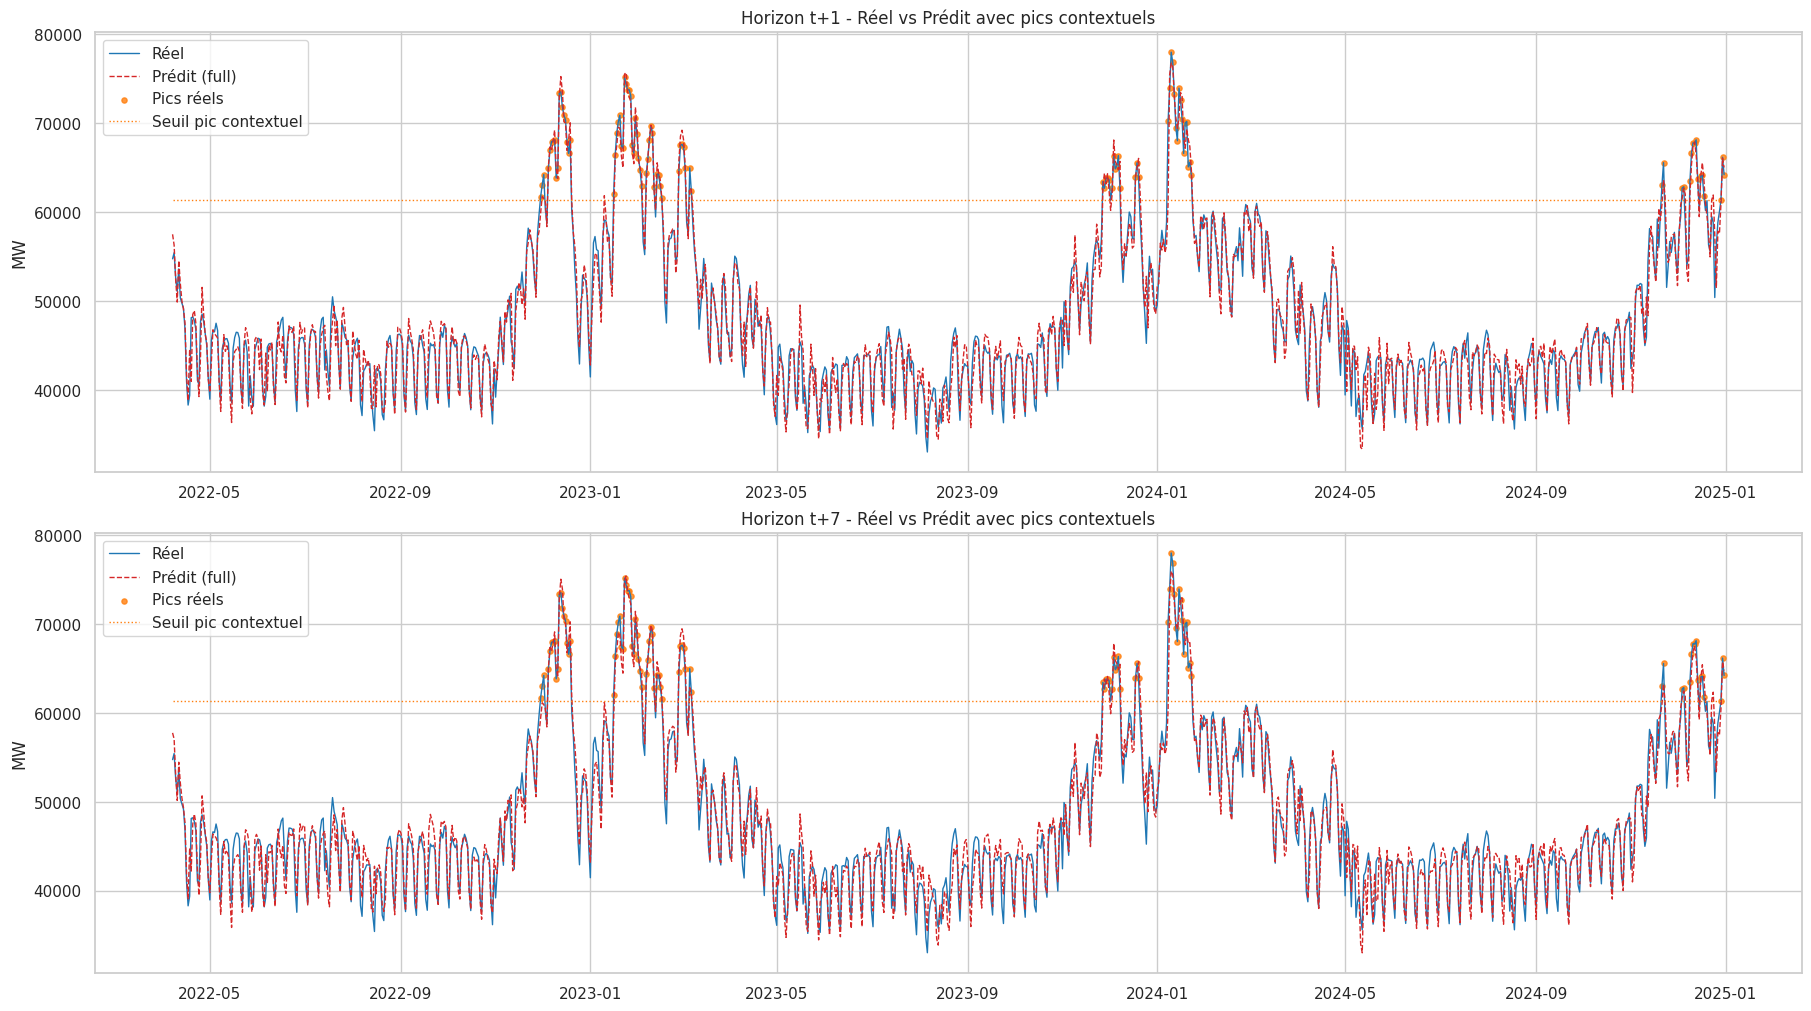

In [73]:
# 1) Série temporelle avec mise en évidence des pics
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(18, 5 * len(HORIZONS)), constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    d = wf_viz[wf_viz["horizon"] == horizon].sort_values("date")
    model_name = selected_models_by_horizon[horizon]

    ax.plot(d["date"], d["actual"], color="#1f77b4", linewidth=1.0, label="Réel")
    ax.plot(d["date"], d["predicted"], color="#d62728", linewidth=1.0, linestyle="--", label=f"Prédit ({model_name})")

    peaks = d[d["is_peak"]]
    ax.scatter(peaks["date"], peaks["actual"], s=14, color="#ff7f0e", alpha=0.8, label="Pics réels")
    ax.plot(d["date"], d["peak_threshold"], color="#ff7f0e", linestyle=":", linewidth=1.0, label="Seuil pic contextuel")

    ax.set_title(f"Horizon t+{horizon} - Réel vs Prédit avec pics contextuels")
    ax.set_ylabel("MW")
    ax.legend(loc="upper left")

plt.show()

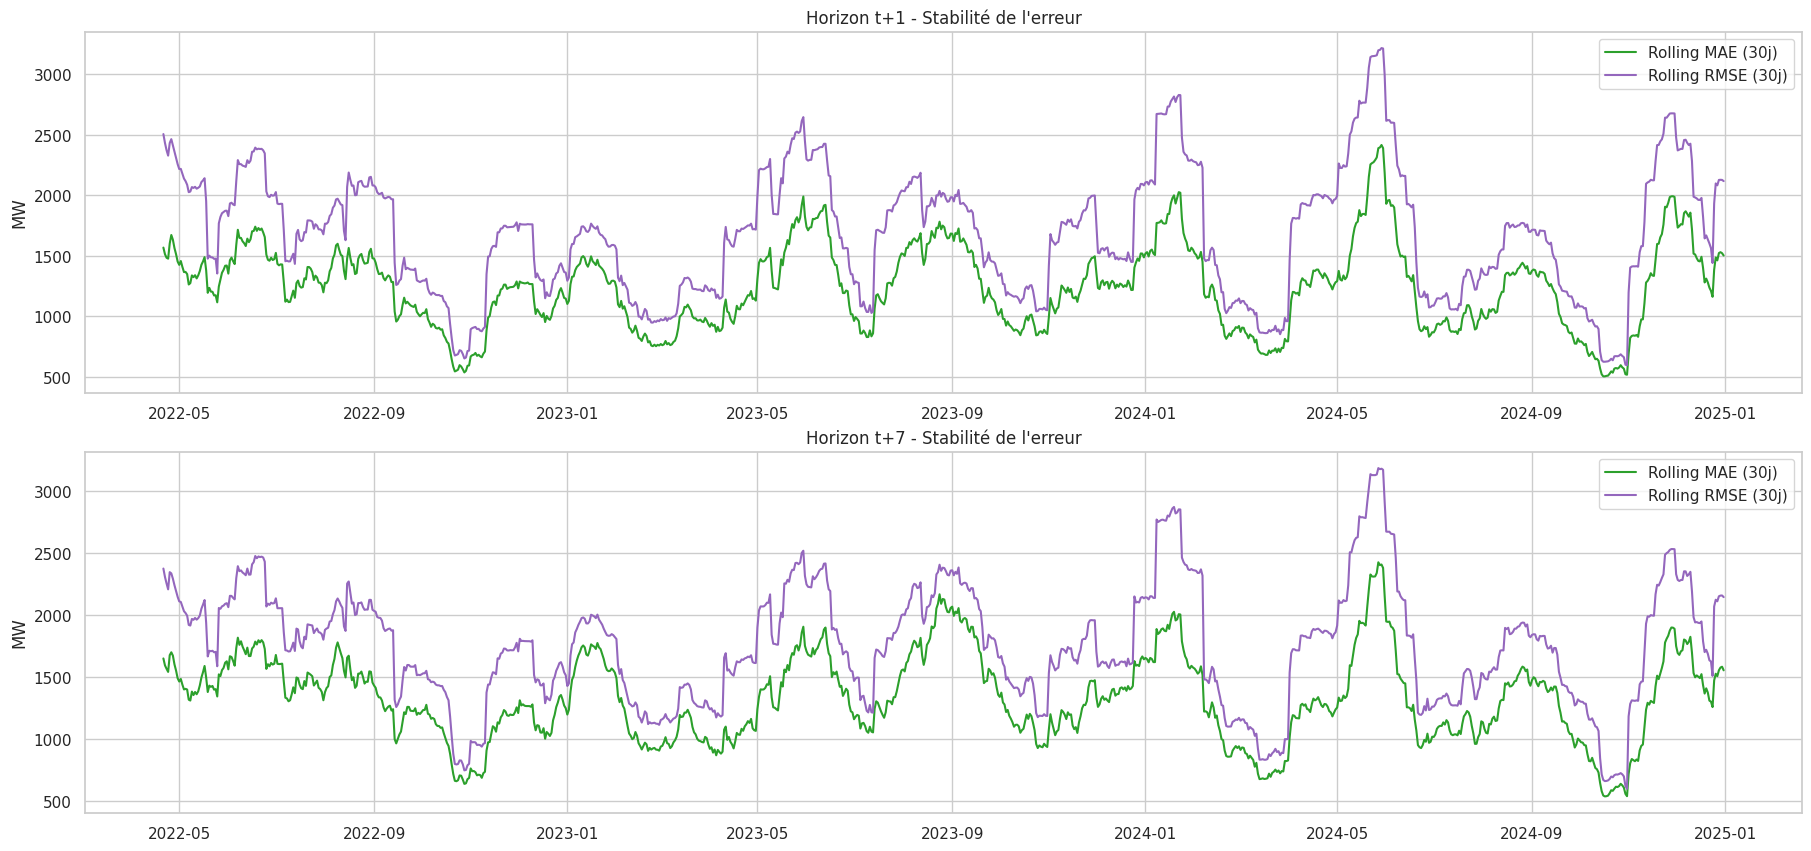

In [74]:
# 2) Erreurs temporelles: rolling MAE / rolling RMSE
rolling_window = 30
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(18, 4.2 * len(HORIZONS)), constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    d = wf_viz[wf_viz["horizon"] == horizon].sort_values("date").copy()
    d["rolling_mae"] = d["abs_error"].rolling(rolling_window, min_periods=rolling_window // 2).mean()
    d["rolling_rmse"] = np.sqrt(d["sq_error"].rolling(rolling_window, min_periods=rolling_window // 2).mean())

    ax.plot(d["date"], d["rolling_mae"], label=f"Rolling MAE ({rolling_window}j)", color="#2ca02c")
    ax.plot(d["date"], d["rolling_rmse"], label=f"Rolling RMSE ({rolling_window}j)", color="#9467bd")
    ax.set_title(f"Horizon t+{horizon} - Stabilité de l'erreur")
    ax.set_ylabel("MW")
    ax.legend()

plt.show()

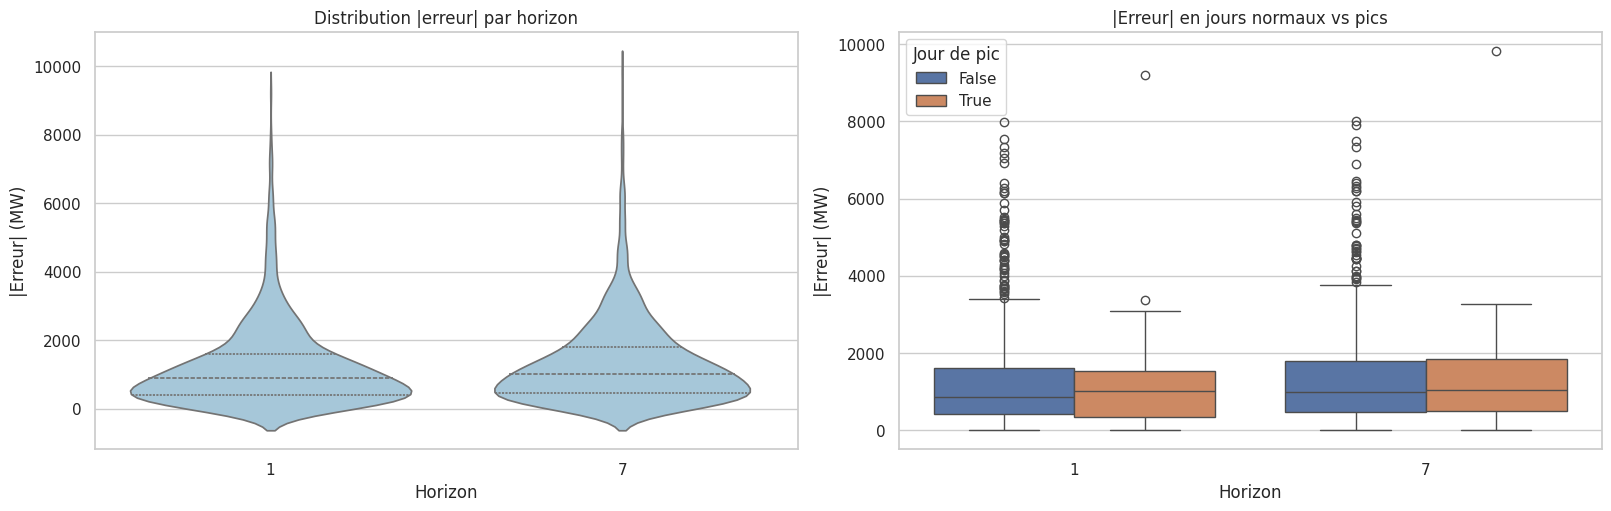

In [75]:
# 3) Distributions des erreurs: global vs pics
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

sns.violinplot(data=wf_viz, x="horizon", y="abs_error", ax=axes[0], inner="quartile", color="#9ecae1")
axes[0].set_title("Distribution |erreur| par horizon")
axes[0].set_xlabel("Horizon")
axes[0].set_ylabel("|Erreur| (MW)")

sns.boxplot(data=wf_viz, x="horizon", y="abs_error", hue="is_peak", ax=axes[1])
axes[1].set_title("|Erreur| en jours normaux vs pics")
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("|Erreur| (MW)")
axes[1].legend(title="Jour de pic")

plt.show()

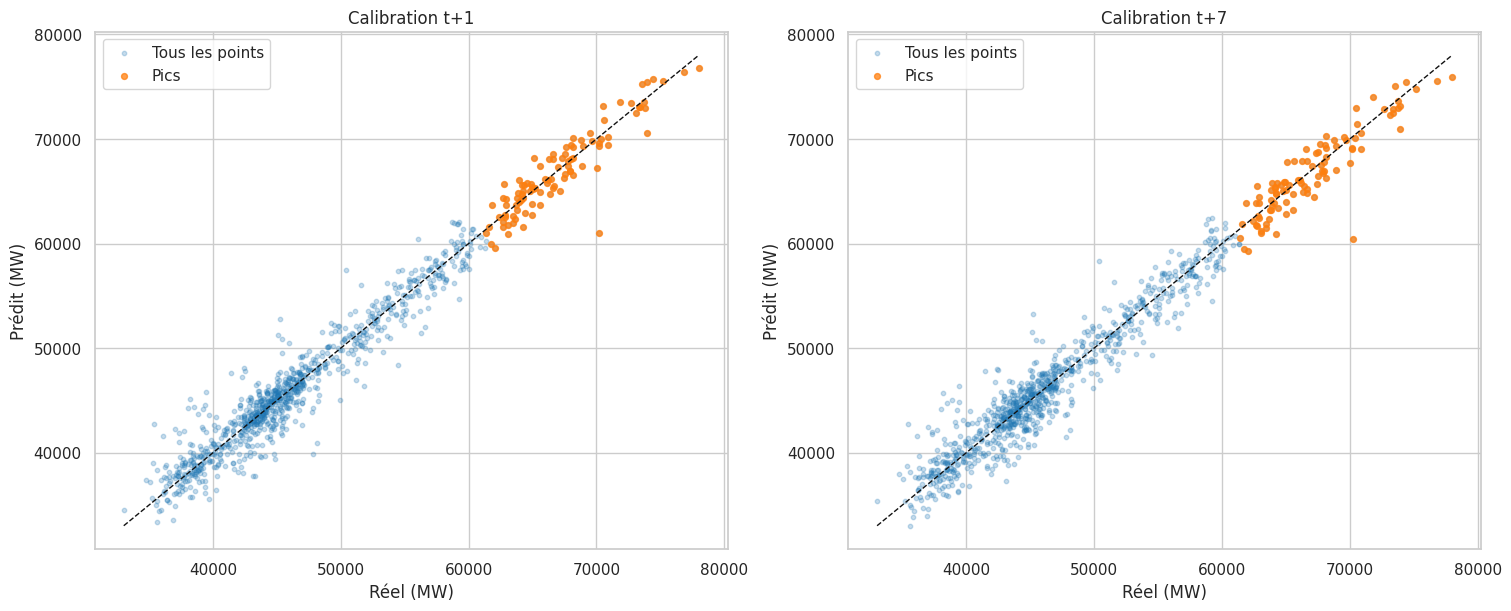

In [76]:
# 4) Calibration: réel vs prédit, et biais sur pics
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(7.5 * len(HORIZONS), 6), constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    d = wf_viz[wf_viz["horizon"] == horizon]
    peaks = d[d["is_peak"]]

    ax.scatter(d["actual"], d["predicted"], s=10, alpha=0.25, color="#1f77b4", label="Tous les points")
    ax.scatter(peaks["actual"], peaks["predicted"], s=18, alpha=0.75, color="#ff7f0e", label="Pics")

    min_v = min(d["actual"].min(), d["predicted"].min())
    max_v = max(d["actual"].max(), d["predicted"].max())
    ax.plot([min_v, max_v], [min_v, max_v], color="#111111", linestyle="--", linewidth=1)

    ax.set_title(f"Calibration t+{horizon}")
    ax.set_xlabel("Réel (MW)")
    ax.set_ylabel("Prédit (MW)")
    ax.legend()

plt.show()

Détection des pics (seuil contextuel variable):


,horizon,threshold_median_mw,threshold_min_mw,threshold_max_mw,TP,FP,FN,TN,precision,recall,f1
0,1,61350.572917,61350.572917,61350.572917,95,7,5,893,0.931373,0.95,0.940594
1,7,61350.572917,61350.572917,61350.572917,93,6,7,894,0.939394,0.93,0.934673


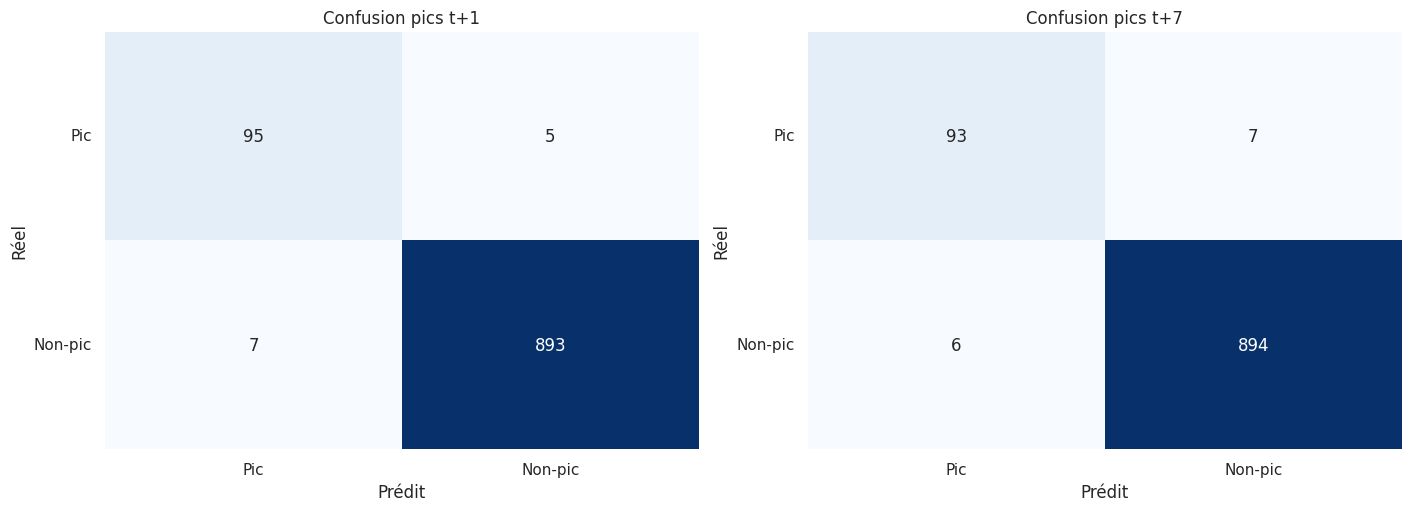

In [77]:
# 5) Qualité de détection des pics (classification opérationnelle)
peak_detection_rows = []

for horizon in HORIZONS:
    d = wf_viz[wf_viz["horizon"] == horizon].copy()

    # Détection basée sur un seuil contextuel variable dans le temps
    y_true_peak = d["actual"] >= d["peak_threshold"]
    y_pred_peak = d["predicted"] >= d["peak_threshold"]

    tp = int((y_true_peak & y_pred_peak).sum())
    fp = int((~y_true_peak & y_pred_peak).sum())
    fn = int((y_true_peak & ~y_pred_peak).sum())
    tn = int((~y_true_peak & ~y_pred_peak).sum())

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

    peak_detection_rows.append({
        "horizon": horizon,
        "threshold_median_mw": float(d["peak_threshold"].median()),
        "threshold_min_mw": float(d["peak_threshold"].min()),
        "threshold_max_mw": float(d["peak_threshold"].max()),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

peak_detection_df = pd.DataFrame(peak_detection_rows).sort_values("horizon")
print("Détection des pics (seuil contextuel variable):")
display(peak_detection_df)

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(7 * len(HORIZONS), 5), constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    row = peak_detection_df[peak_detection_df["horizon"] == horizon].iloc[0]
    cm = np.array([[row["TP"], row["FN"]], [row["FP"], row["TN"]]])
    sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Confusion pics t+{horizon}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.set_xticklabels(["Pic", "Non-pic"])
    ax.set_yticklabels(["Pic", "Non-pic"], rotation=0)

plt.show()

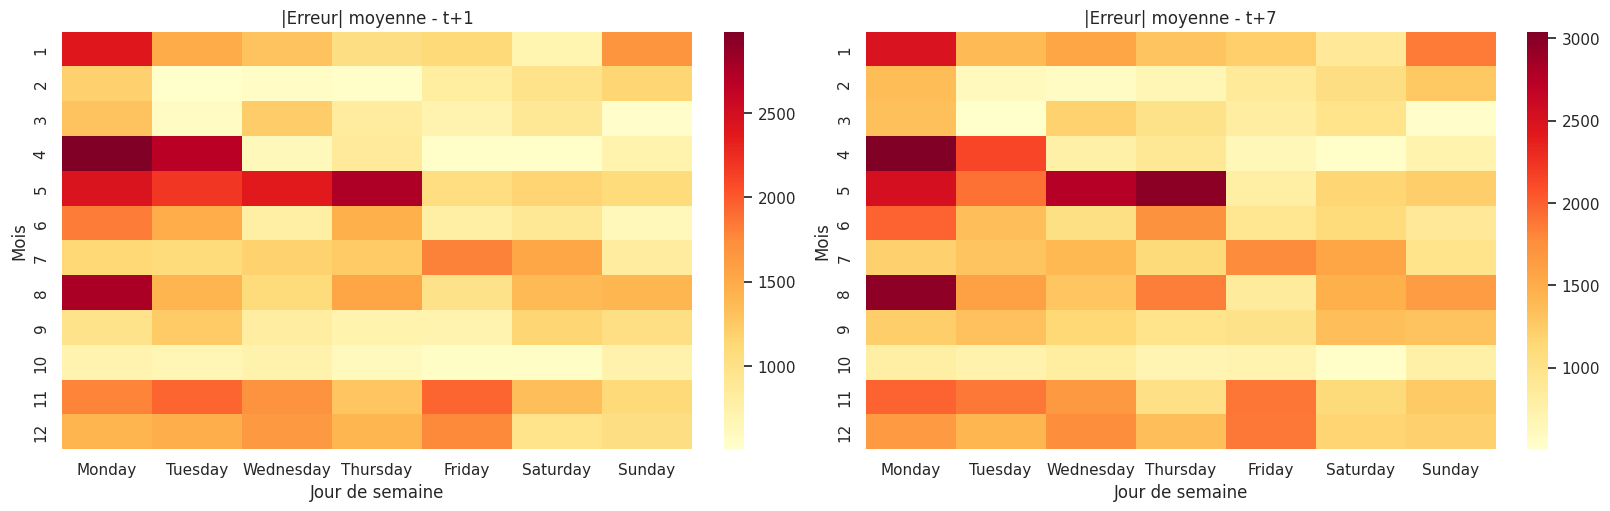

In [78]:
# 6) Heatmaps de saisonnalité des erreurs (mois x jour de semaine)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(8 * len(HORIZONS), 5), constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    d = wf_viz[wf_viz["horizon"] == horizon].copy()
    pivot = d.pivot_table(index="month", columns="day_name", values="abs_error", aggfunc="mean")
    pivot = pivot.reindex(columns=weekday_order)

    sns.heatmap(pivot, cmap="YlOrRd", annot=False, ax=ax)
    ax.set_title(f"|Erreur| moyenne - t+{horizon}")
    ax.set_xlabel("Jour de semaine")
    ax.set_ylabel("Mois")

plt.show()

Top 20 erreurs sur pics par horizon:


,date,horizon,model,actual,predicted,error,abs_error,signed_pct_error
0,2024-01-08,1,full,70239.062500,61029.815038,-9209.247462,9209.247462,-13.111290
1,2024-01-15,1,full,73960.416667,70594.700808,-3365.715858,3365.715858,-4.550699
2,2024-01-21,1,full,65103.645833,68194.945982,3091.300149,3091.300149,4.748275
3,2023-12-08,1,full,62747.395833,65724.311387,2976.915553,2976.915553,4.744285
4,2024-01-19,1,full,70040.625000,67195.198661,-2845.426339,2845.426339,-4.062537
5,2022-12-02,1,full,64239.583333,61561.306929,-2678.276405,2678.276405,-4.169200
6,2024-01-17,1,full,70501.562500,73146.681987,2645.119487,2645.119487,3.751859
7,2023-01-16,1,full,62060.937500,59551.159429,-2509.778071,2509.778071,-4.044054
8,2023-03-06,1,full,64995.833333,62729.010324,-2266.823010,2266.823010,-3.487644
9,2023-01-22,1,full,67191.145833,65014.846701,-2176.299132,2176.299132,-3.238967


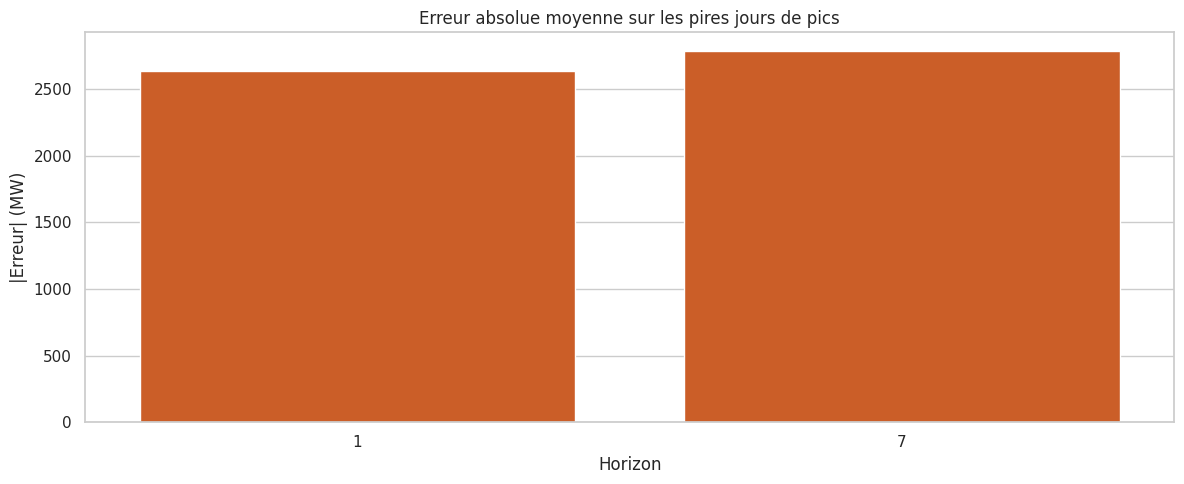

In [79]:
# 7) Analyse des pires erreurs sur pics (tableau opérationnel)
top_n = 20
worst_peak_rows = []

for horizon in HORIZONS:
    d = wf_viz[(wf_viz["horizon"] == horizon) & (wf_viz["is_peak"])].copy()
    d = d.sort_values("abs_error", ascending=False).head(top_n)
    d["signed_pct_error"] = (d["error"] / d["actual"]) * 100
    d["model"] = selected_models_by_horizon[horizon]
    worst_peak_rows.append(d[["date", "horizon", "model", "actual", "predicted", "error", "abs_error", "signed_pct_error"]])

worst_peak_df = pd.concat(worst_peak_rows, ignore_index=True).sort_values(["horizon", "abs_error"], ascending=[True, False])
print(f"Top {top_n} erreurs sur pics par horizon:")
display(worst_peak_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=worst_peak_df, x="horizon", y="abs_error", estimator="mean", errorbar=None, color="#e6550d")
plt.title("Erreur absolue moyenne sur les pires jours de pics")
plt.xlabel("Horizon")
plt.ylabel("|Erreur| (MW)")
plt.tight_layout()
plt.show()